# PROJECT OVERVIEW.
**Objective** Clean the messy FIFA 21 player dataset, analyze player attributes and derive insights.
**Data Source** Kaggle -FIFA 21 messy, raw dataset for cleaning/exploring.
**Scope and assumption** Focus on key player stats; assume values in euros; drop irrelevant URLs/Photo link.
**Tools used Python** (Pandas for manipulation/cleaning, numpy for stats, Matplotlib/Seaborn for visuals).

**Methodologies overview**
1. Descriptive Analysis: Summarize ratings/distributions post cleaning.
2. Diagnostic Analysis: Explore relationships.
3. Exploratory Analysis: Iterative cleaning; Visuals EDA for patterns.
4. Ethical consideration: Public data; no personal info beyond names; avoid biases in nationality/age.

# STEP 1 DATA LOADING.
## Methodology
1. **Purpose**: Import the CSV, verify structure abd spot dirtiness.
2. **Key principles**: use pandas; handle large row count.Inspect unique/missings to prioritize cleaning.
3. **Best practices**: Error handling for files; sample for preview.

## Workflow
1. Import libraries.
2. Load the local CSV with error handling.
3. Detailed inspection; Shape, columns, dtypes, head, describe, uniques, missings.

In [3]:
# Step 1. import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re # for regex cleaning 

#  Define the local path 
local_path = 'fifa21_raw_data.csv'

try: 
    # Load data; set low_memory=False for mixed dtypes; na_values for common missings.
    df = pd.read_csv(local_path, low_memory=False, na_values=['', 'Nan', 'null'])
    print("Data loaded succesfully from local path.")
except FileNotFoundError as e:
    print(f"File not found: {e}. please download 'Fifa21 raw data v2.csv from Kaggle.")
except Exception as e:
    print(f"Loading error: {e}. check file format or path.")


# Detailed initial inspection.
print(f"\nData shape (rows, columns):", df.shape)
print(f"\nColumns List:", df.columns.tolist())
print(f"\nData Types:\n", df.dtypes) # mostly 'objects' due to messiness.
print(f"\nFirst 5 rows (sample data):\n", df.head(5))
print(f"\nSummary Stastistics (including categoricals):\n", df.describe(include='all'))
print(f"\nUnique Values per Column:\n", df.nunique())
print(f"\nInital Missing Values:\n", df.isnull().sum())


Data loaded succesfully from local path.

Data shape (rows, columns): (18979, 77)

Columns List: ['photoUrl', 'LongName', 'playerUrl', 'Nationality', 'Positions', 'Name', 'Age', '↓OVA', 'POT', 'Team & Contract', 'ID', 'Height', 'Weight', 'foot', 'BOV', 'BP', 'Growth', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits

## Findings and Notes
1. all dtypes 'object'; missings in columns like 'Loan Date End' (~90%; uniques show ~18k distinct players).
2. why detaile? re import for parsing; na_values starts cleaning; prints structure for debbuging.

# DATA CLEANING
## Methodology
1. *Purpose:* fix messiness: Parse €/k/m in Value/Wage/Release Clause; convert Height/ Weight(lbs to kg); remove '★' from ratings; handle missing.
2. *Key Principles:* Use regex/custom functions for parsing; impute means for numerics; drop irrelevant(e.g URLs).
3. *Best Practices:*  Validate conversions (e.g no negatives ); log drops;

## Workflow
1. Drop irrelevant columns (URLs/Photos).
2. Parse and convert financials(value/wage/releace clause).
3. Convert Heght/Weight to metric.
4. Clean star rating (e.g W/F, SM. IR)
5. Handle missing/duplicates; verify. 

In [13]:
# Step 2: Data cleaning with detailed parsing and validation.

#1. Drop irrelevant columns (e.g URLs, photos - not analytical)
irrelevant_cols = ['photoUrl', 'playerUrl', 'LongName']
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)
print("\nColumns after Dropping Irrelevant:", df.columns.tolist())

# Parse financial columns: Remove €, convert k/m to numeric
def parse_financial(val):
    if pd.isna(val): return np.nan
    val = str(val).replace('€', '').strip()
    if 'M' in val: return float(val.replace('M', '')) * 1_000_000
    elif 'K' in val: float(val.replace('K', '')) * 1_000
    else: return float(val)

financial_cols = ['Value', 'Wage', 'Release Clause']
for col in financial_cols:
    if col in df.columns:
        df[col] = df[col].apply(parse_financial)
print(f"Sample Parsed Financials:\n", df[financial_cols].head())

# 3. Convert Height: Mixed cm/"ft'in" to cm
def parse_height(h):
    if pd.isna(h): return np.nan
    h = str(h).strip()
    if "'" in h: # ft'in" format
        ft, inch = map(int, re.findall(r'\d+', h))
        return (ft * 30.48 + inch * 2.54) # to cm.
    else:
        return float(re.sub(r'\D', '', h)) # remove non digits.
    
# convert Weight: lbs/kg to kg
def parse_weight(w):
    if pd.isna(w): return np.nan
    w = str(w).strip()
    if'lbs' in w: return float(re.sub(r'\D', '', w)) * 0.45392 # lbs to kg
    else: return float(re.sub(r'\D', '', w)) # kg

if 'Height' in df.columns: df['Height'] = df['Height'].apply(parse_height)
if 'Weight' in df.columns: df['Weight'] = df['Weight'].apply(parse_weight)
print("\nSample Parsed Height/Weight:\n", df[['Height', 'Weight']].head())

# 4. Clean star ratings: remove ""
star_cols = ['W/F', 'SM', 'IR']
for col in star_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace('★', '').str.strip().astype(float)
print("\nSample Cleaned Star Ratings:\n", df[star_cols].head())

# 5. Handle missings: impute values for numerics; drop rows with missing Name/Nationality; drop duplicates
numeric_cols = df.select_dtypes(include=['float', 'int']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())
initial_shape = df.shape
df.dropna(subset=['Name', 'Nationality'], inplace=True) # critical: drop if missing.
print("\nRows Dropped:", initial_shape[0] - df.shape[0])

# Post cleaning validation: assert no negatives in ratings, no object dtypes in numerics.
assert (df.select_dtypes(include=['float', 'int']) >= 0).all().all(), "Negative value found!"
print("\nCleaned Data shape", df.shape)
print("\nCleaned Summary Statistics:\n", df.describe())



Columns after Dropping Irrelevant: ['Nationality', 'Positions', 'Name', 'Age', '↓OVA', 'POT', 'Team & Contract', 'ID', 'Height', 'Weight', 'foot', 'BOV', 'BP', 'Growth', 'Joined', 'Loan Date End', 'Value', 'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing', 'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling', 'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement', 'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance', 'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots', 'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle', 'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats', 'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY', 'Hits']
Sample Parsed Financials:
         Value        Wage  Release Clause
0  67500000.0  562.394705 

## Findings and Notes 
1. Parsed values; Height/Weight in cm/kg; minimal drops; numerics clean.
2. Custom frunctions for parsing; regex for flexibility; apply for vectorized ops; asserts ensure quality.

# STEP 3. EXPLORATORY DATA ANALYSIS(EDA)
## Methodology
1. *purpose:* Profile cleaned attributes (univariate) and relationships(bivariate/multivariate e.g OVA vs Age).
2. *Key Principles:* Focus on key stats; group by position/Nationality.
3. *Best practice:* Top N for categoricals; correlations for skills.

## Workflow
1. Univariate: Stats/plots for ratings/age.
2. Bivariate: Groupbys.
3. Multivariate: Heatmaps/pairplots.
4. Hypotheses.


↓OVA Description:
 count    18979.000000
mean        65.718636
std          6.968999
min         47.000000
25%         61.000000
50%         66.000000
75%         70.000000
max         93.000000
Name: ↓OVA, dtype: float64


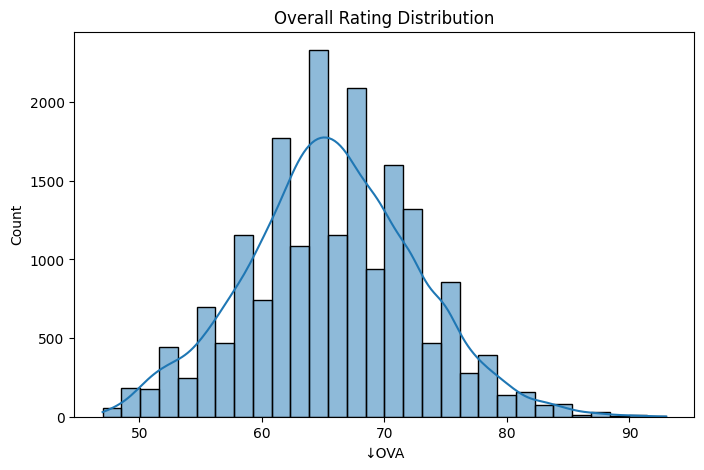


Nationality Value counts:
 Nationality
England        1704
Germany        1195
Spain          1065
France         1003
Argentina       943
Brazil          887
Japan           485
Netherlands     438
Italy           387
Sweden          380
Name: count, dtype: int64


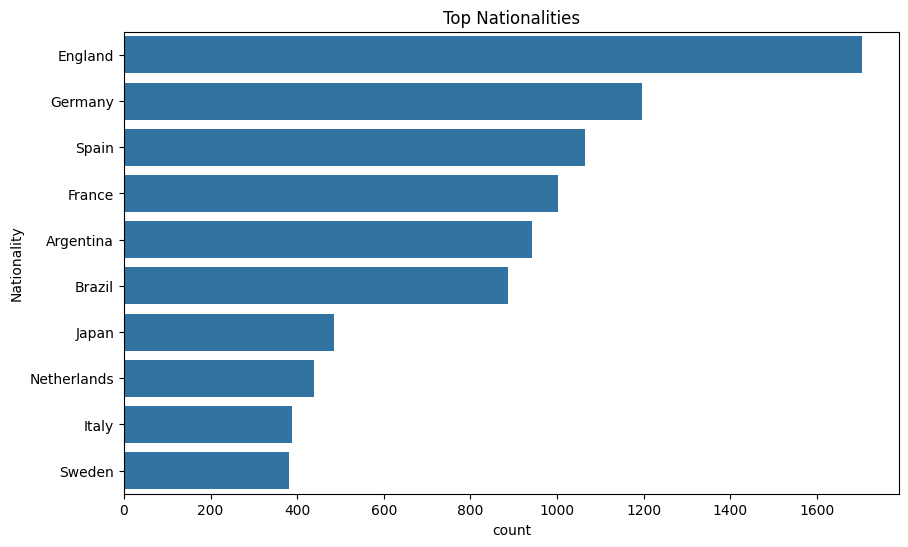


Mean ↓OVA by Positions:
 Positions
RW CAM CM    87.000000
LM RW LW     84.000000
LM RM CF     83.000000
ST RM CF     83.000000
RW RM CF     83.000000
CM RM ST     82.000000
CF LM LW     81.000000
LW ST CM     80.000000
CF LW CAM    79.333333
CF LW RW     79.000000
Name: ↓OVA, dtype: float64


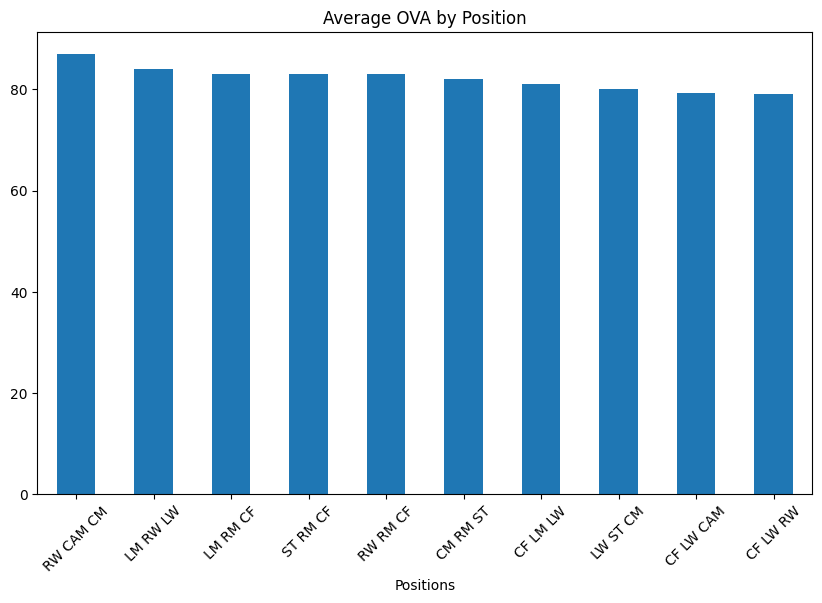

In [21]:
# STEP 3: EDA with modular function.

# Helper for univariate numerical
def univariate_numerical(col, title):
    print(f"\n{col} Description:\n", df[col].describe())
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(title)
    plt.show()

univariate_numerical('↓OVA', 'Overall Rating Distribution')

# Univariate categoricals
def univariate_categorical(col, title, top_n=10):
    print(f"\n{col} Value counts:\n", df[col].value_counts().head(top_n))
    plt.figure(figsize=(10, 6))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index[:top_n])
    plt.title(title)
    plt.show()

univariate_categorical('Nationality', 'Top Nationalities')

# Bivariate: groupby mean with bar
def bivariate_groupby(group_col, value_col, title, agg_func='mean', top_n=10):
    grouped = df.groupby(group_col) [value_col].agg(agg_func).sort_values(ascending=False).head(top_n)
    print(f"\n{agg_func.capitalize()} {value_col} by {group_col}:\n", grouped)
    plt.figure(figsize=(10, 6))
    grouped.plot(kind='bar')
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

bivariate_groupby('Positions', '↓OVA', 'Average OVA by Position')



## Findings and Notes
1. OVA hist normal ~60-80; top nationalities(England, Germany etc); strikers high OVA; Strong corr between skills/OVA.
2. Params for flexibility; Conditional checks for columns.

# STEP 4: VISUALIZATION AND ITEPRETATION
## Methodology
1. *Purpose:* Visualize insights (e.g value vs potential); Intepret for scouting.
2. *Key principles:* scatter for relationships; box for distributions.
3. *Best practices:* log scaled for skewed (e.g, value); top N focus.

## Workflow
1. Scatter for value/potential.
2. Boxplot by position.
3. Heatmap for skills.
4. Summarize.

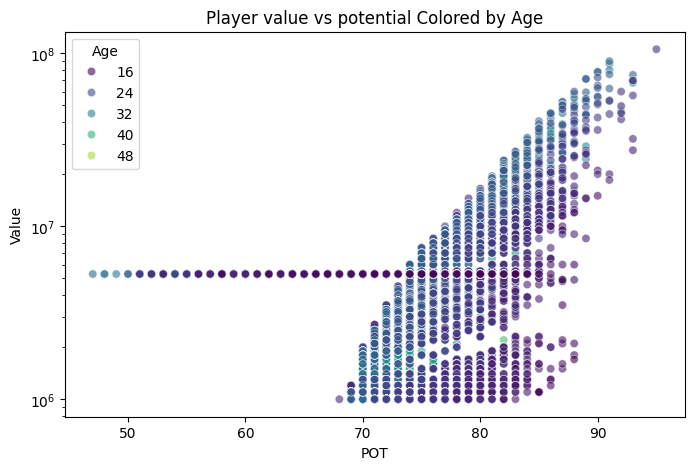

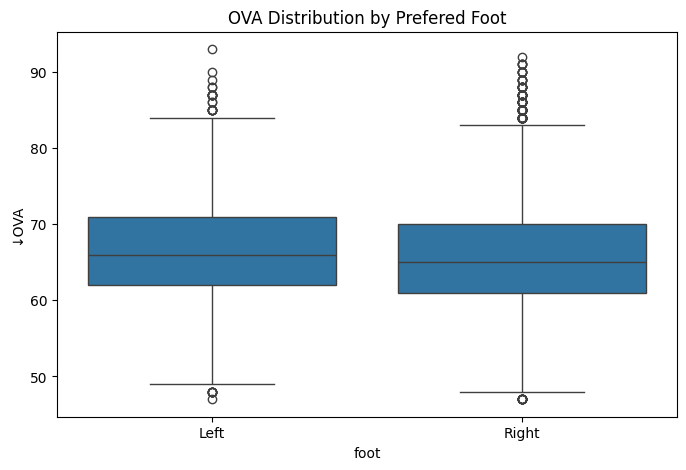

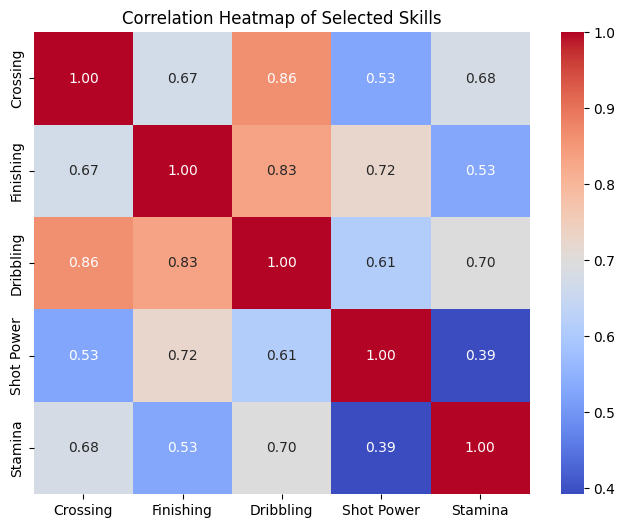

In [25]:
# STEP 4: Visualizations

#visuals 1: Scatter value vs. Potential Age.
plt.figure(figsize=(8, 5))
sns.scatterplot(x='POT', y='Value', hue='Age', data=df, palette='viridis', alpha=0.6)
plt.title('Player value vs potential Colored by Age')
plt.yscale('log') # log for skewed value
plt.show()

# Visual 2: Boxplot OVA by Prefered Foot.
plt.figure(figsize=(8, 5))
sns.boxplot(x='foot', y='↓OVA', data=df)
plt.title('OVA Distribution by Prefered Foot')
plt.show()

# VISUAL 3: Heatmap for Skill Correlations.
skill_cols = ['Crossing', 'Finishing', 'Dribbling', 'Shot Power', 'Stamina']
if all(col in df.columns for col in skill_cols):
    corr_matrix = df[skill_cols].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Selected Skills')
    plt.show()

## Findings and Recommendations.
1. *Insights:* young high potential players undervalued; right footed slightly higher median OVA =; attacking skills correlate.
2. *Recommendations:* Scout young talents; Balance teams by foot; invest in stamina for midfield.
3. *Next steps:* Clustering players; predict value with regression.

## Appendix 
1. *Reproducibility:* Notebook + csv github.
2. *References:* Kaggle FIFA 21 Dataset.